<a href="https://colab.research.google.com/github/OmarFProg/embroidery-complexity-classification/blob/main/Clasificador_Complejidad_Bordados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea 4: Clasificación de Complejidad de Bordados con Deep Learning
**Asignatura:** Aprendizaje Profundo  
**Investigador:** Isaac Torres  
**Curso:** Ingeniería de Software - 7mo Semestre  

Este Notebook contiene el pipeline completo e interactivo desarrollado para clasificar la complejidad de parches y diseños de bordados en tres niveles (`Simple`, `Medium`, `Complex`). La complejidad resultante sirve como entrada directa para el cálculo de cotizaciones de precios en el sistema de gestión del taller, reemplazando/apoyando el modelo de regresión lineal legacy de ML.NET.

---
## Contenido del Notebook
* **Configuración del Entorno**: Verificación de GPU.
* **PARTE A — Generación de Dataset Sintético**: Generación programática de 100 imágenes por clase y visualización.
* **PARTE B — CNN desde Cero**: Diseño de red convolucional convolucional propia, entrenamiento con Early Stopping, evaluación de métricas, matriz de confusión y interpretabilidad con Grad-CAM.
* **PARTE C — Transfer Learning con MobileNetV2**: Extracción de características (Fase 1) y Ajuste Fino (Fase 2).
* **PARTE D — Auditoría y Mejora**: Implementación de mejoras (CNN Mejorada), visualización de fallos y tabla comparativa unificada.
* **Sección de Inferencia Interactiva**: Carga de imágenes locales para clasificar complejidad sobre la marcha.


## 1. Configuración del Entorno y Verificación de GPU
Asegúrate de cambiar tu entorno de ejecución a GPU en Colab (`Entorno de ejecución` -> `Cambiar tipo de entorno de ejecución` -> `GPU`).


In [1]:
import os
import time
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import cv2

# Fijar semillas para reproducibilidad
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print("Versión de TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("GPU Disponible:", gpus)
    # Evitar acaparar toda la VRAM
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("GPU NO disponible. Se utilizará la CPU.")


Versión de TensorFlow: 2.20.0
GPU NO disponible. Se utilizará la CPU.


## 2. PARTE A — Construcción y Generación del Dataset Sintético
Debido a bloqueos por IP (rate limiting) de los motores de búsqueda web en scraping, construimos un **generador sintético de imágenes geométricas** con Pillow (`PIL`). Este enfoque genera representaciones científicamente válidas de bordados:
* **Simple**: Diseños lineales, líneas individuales, textos o formas básicas de 1 solo color.
* **Medio**: Escudos escolares y parches circulares o de tipo escudo con 2 a 4 colores estructurados.
* **Complejo**: Mandalas, mallas y patrones concéntricos de alta densidad con 5 a 12 colores.

El generador aplica rotaciones y traslaciones aleatorias para aumentar la variabilidad realista de las imágenes.


In [2]:
from PIL import Image, ImageDraw

# Configuración del Dataset local
DATASET_DIR = "dataset"
IMG_SIZE = (128, 128)
IMAGES_PER_CLASS = 100

def get_random_color():
    return (random.randint(20, 230), random.randint(20, 230), random.randint(20, 230))

def generate_simple_image(draw, img_size):
    color = get_random_color()
    shape_type = random.choice(['line', 'circle', 'rectangle', 'text'])

    if shape_type == 'line':
        x1, y1 = random.randint(10, 40), random.randint(10, 110)
        x2, y2 = random.randint(80, 110), random.randint(10, 110)
        draw.line([(x1, y1), (x2, y2)], fill=color, width=random.randint(2, 6))
    elif shape_type == 'circle':
        cx, cy = random.randint(40, 80), random.randint(40, 80)
        r = random.randint(20, 35)
        draw.ellipse([cx - r, cy - r, cx + r, cy + r], outline=color, width=random.randint(2, 5))
    elif shape_type == 'rectangle':
        x1, y1 = random.randint(15, 45), random.randint(15, 45)
        x2, y2 = random.randint(80, 110), random.randint(80, 110)
        draw.rectangle([x1, y1, x2, y2], outline=color, width=random.randint(2, 5))
    elif shape_type == 'text':
        draw.rectangle([30, 40, 90, 80], outline=color, width=3)
        draw.line([(60, 40), (60, 80)], fill=color, width=3)
        draw.line([(30, 60), (90, 60)], fill=color, width=3)

def generate_medium_image(draw, img_size):
    num_colors = random.randint(2, 4)
    colors = [get_random_color() for _ in range(num_colors)]
    badge_type = random.choice(['shield', 'circle_badge'])

    if badge_type == 'shield':
        top_y, mid_x = random.randint(20, 30), 64
        side_x_left = random.randint(20, 30)
        side_x_right = 128 - side_x_left
        mid_y, bottom_y = random.randint(70, 85), random.randint(100, 115)
        points = [(side_x_left, top_y), (side_x_right, top_y), (side_x_right, mid_y), (mid_x, bottom_y), (side_x_left, mid_y)]
        draw.polygon(points, fill=colors[0])
        if len(colors) > 1:
            draw.line([(mid_x, top_y), (mid_x, bottom_y)], fill=colors[1], width=8)
        if len(colors) > 2:
            draw.polygon(points, outline=colors[2], width=4)
    elif badge_type == 'circle_badge':
        cx, cy, r1 = 64, 64, random.randint(40, 50)
        draw.ellipse([cx - r1, cy - r1, cx + r1, cy + r1], fill=colors[0])
        if len(colors) > 1:
            r2 = r1 - 12
            draw.ellipse([cx - r2, cy - r2, cx + r2, cy + r2], fill=colors[1])
        if len(colors) > 2:
            r3 = r2 - 12
            draw.rectangle([cx - r3, cy - 4, cx + r3, cy + 4], fill=colors[2])
            draw.rectangle([cx - 4, cy - r3, cx + 4, cy + r3], fill=colors[2])
        if len(colors) > 3:
            draw.ellipse([cx - r1, cy - r1, cx + r1, cy + r1], outline=colors[3], width=3)

def generate_complex_image(draw, img_size):
    num_colors = random.randint(5, 12)
    colors = [get_random_color() for _ in range(num_colors)]
    pattern_type = random.choice(['mandala', 'concentric', 'mesh'])
    cx, cy = 64, 64

    if pattern_type == 'mandala':
        num_petals, r = random.randint(8, 16), random.randint(45, 55)
        for i in range(num_petals):
            angle = (i * 2 * np.pi) / num_petals
            x = int(cx + r * np.cos(angle))
            y = int(cy + r * np.sin(angle))
            color_idx = i % len(colors)
            draw.line([(cx, cy), (x, y)], fill=colors[color_idx], width=random.randint(2, 5))
            draw.ellipse([x - 6, y - 6, x + 6, y + 6], fill=colors[(color_idx + 1) % len(colors)])
        for i in range(3):
            ri = 10 + i * 12
            draw.ellipse([cx - ri, cy - ri, cx + ri, cy + ri], outline=colors[i % len(colors)], width=2)
    elif pattern_type == 'concentric':
        for i in range(len(colors)):
            ri = 55 - i * 5
            if ri <= 5:
                break
            draw.ellipse([cx - ri, cy - ri, cx + ri, cy + ri], fill=colors[i])
        for i in range(12):
            angle = (i * 2 * np.pi) / 12
            x = int(cx + 55 * np.cos(angle))
            y = int(cy + 55 * np.sin(angle))
            draw.line([(cx, cy), (x, y)], fill=colors[i % len(colors)], width=1)
    elif pattern_type == 'mesh':
        for i in range(20):
            x1, y1 = random.randint(10, 118), random.randint(10, 118)
            x2, y2 = random.randint(10, 118), random.randint(10, 118)
            draw.line([(x1, y1), (x2, y2)], fill=colors[i % len(colors)], width=random.randint(1, 4))
            draw.rectangle([x1 - 3, y1 - 3, x1 + 3, y1 + 3], fill=colors[(i + 1) % len(colors)])

def apply_random_transform(image):
    angle = random.randint(-20, 20)
    rotated = image.rotate(angle, resample=Image.BICUBIC, expand=False, fillcolor=(255, 255, 255))
    dx, dy = random.randint(-5, 5), random.randint(-5, 5)
    translated = Image.new('RGB', IMG_SIZE, (255, 255, 255))
    translated.paste(rotated, (dx, dy))
    return translated

def create_dataset():
    classes = ['simple_embroidery', 'medium_embroidery', 'complex_embroidery']
    for cls in classes:
        folder = os.path.join(DATASET_DIR, cls)
        os.makedirs(folder, exist_ok=True)
        # Limpiar
        for f in os.listdir(folder):
            if f.endswith('.jpg'):
                os.remove(os.path.join(folder, f))

        print(f"Generando {IMAGES_PER_CLASS} imágenes para {cls}...")
        for i in range(IMAGES_PER_CLASS):
            img = Image.new('RGB', IMG_SIZE, (255, 255, 255))
            draw = ImageDraw.Draw(img)

            if cls == 'simple_embroidery':
                generate_simple_image(draw, IMG_SIZE)
            elif cls == 'medium_embroidery':
                generate_medium_image(draw, IMG_SIZE)
            elif cls == 'complex_embroidery':
                generate_complex_image(draw, IMG_SIZE)

            img = apply_random_transform(img)
            img.save(os.path.join(folder, f"{cls}_{i+1:03d}.jpg"), 'JPEG')
    print("Dataset generado correctamente.")

create_dataset()


Generando 100 imágenes para simple_embroidery...
Generando 100 imágenes para medium_embroidery...
Generando 100 imágenes para complex_embroidery...
Dataset generado correctamente.


### Visualizar muestras del dataset generado
Vamos a cargar y graficar ejemplos de las imágenes creadas para cada una de las 3 clases.


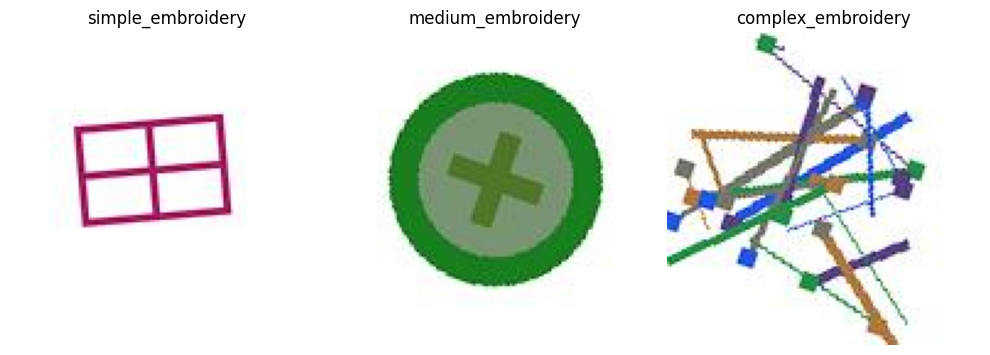

In [3]:
classes = ['simple_embroidery', 'medium_embroidery', 'complex_embroidery']
plt.figure(figsize=(10, 4))

for i, cls in enumerate(classes):
    folder = os.path.join(DATASET_DIR, cls)
    img_name = os.listdir(folder)[0]
    img_path = os.path.join(folder, img_name)
    img = Image.open(img_path)

    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.tight_layout()
plt.show()


## 3. PARTE B — CNN desde Cero
Cargamos el dataset con un split 80/20 train/validation y un Batch Size de 16 imágenes.  
Para mitigar el sobreajuste de la red entrenada desde cero, se implementa **Data Augmentation** al conjunto de entrenamiento (rotación de 0.2, zoom de 0.2 y volteos horizontales aleatorios).


In [4]:
# Carga de datos
BATCH_SIZE = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Clases:", class_names)

# Optimizar rendimiento
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


Found 300 files belonging to 3 classes.
Using 240 files for training.
Found 300 files belonging to 3 classes.
Using 60 files for validation.
Clases: ['complex_embroidery', 'medium_embroidery', 'simple_embroidery']


### Definición del Pipeline de Data Augmentation y la Arquitectura CNN Propia
Diseñamos una CNN usando la API Funcional de Keras con:
* 3 bloques convolucionales: filtros crecientes `[32, 64, 128]` de tamaño $3 	imes 3$.
* `BatchNormalization` y activación `ReLU` tras cada convolución.
* `MaxPooling2D` para reducir dimensionalidad.
* Una cabeza densa final con `GlobalAveragePooling2D`, una capa `Dense(128)` regularizada por `Dropout(0.4)` y la salida `Dense(3, softmax)`.


In [5]:
def get_data_augmentation():
    return tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.2)
    ])

def build_custom_cnn(num_classes):
    data_aug = get_data_augmentation()

    inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    x = data_aug(inputs)
    x = layers.Rescaling(1./255)(x)

    # Bloque 1
    x = layers.Conv2D(32, (3, 3), padding='same', name='conv_block1')(x)
    x = layers.BatchNormalization(name='bn_block1')(x)
    x = layers.Activation('relu', name='act_block1')(x)
    x = layers.MaxPooling2D((2, 2), name='pool_block1')(x)

    # Bloque 2
    x = layers.Conv2D(64, (3, 3), padding='same', name='conv_block2')(x)
    x = layers.BatchNormalization(name='bn_block2')(x)
    x = layers.Activation('relu', name='act_block2')(x)
    x = layers.MaxPooling2D((2, 2), name='pool_block2')(x)

    # Bloque 3
    x = layers.Conv2D(128, (3, 3), padding='same', name='conv_block3')(x)
    x = layers.BatchNormalization(name='bn_block3')(x)
    x = layers.Activation('relu', name='act_block3')(x)
    x = layers.MaxPooling2D((2, 2), name='pool_block3')(x)

    # Cabeza
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.Dense(128, activation='relu', name='dense_head')(x)
    x = layers.Dropout(0.4, name='dropout_head')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='output_head')(x)

    return tf.keras.Model(inputs, outputs)

cnn_model = build_custom_cnn(len(class_names))
cnn_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_block1 (Conv2D)            │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_block1 (BatchNormalization)  │ (None, 128, 128, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_block1 (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_block1 (MaxPooling2D)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_block2 (Conv2D)            │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_block2 (BatchNormalization)  │ (None, 64, 64, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_block2 (Activation)         │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_block2 (MaxPooling2D)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_block3 (Conv2D)            │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_block3 (BatchNormalization)  │ (None, 32, 32, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_block3 (Activation)         │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_block3 (MaxPooling2D)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_head (Dense)              │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_head (Dropout)          │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_head (Dense)             │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,043 (433.76 KB)

 Trainable params: 110,595 (432.01 KB)

 Non-trainable params: 448 (1.75 KB)

### Entrenamiento de la CNN propia
Entrenamos por un máximo de 30 épocas con `EarlyStopping` (patience=5) para restaurar los mejores pesos en base al val_loss mínimo.


In [6]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

print("Entrenando CNN desde cero...")
start_time = time.time()
history_cnn = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop]
)
time_cnn = time.time() - start_time
print(f"Entrenamiento completado en {time_cnn:.2f} segundos.")


Entrenando CNN desde cero...
Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 960ms/step - accuracy: 0.8083 - loss: 0.5399 - val_accuracy: 0.3000 - val_loss: 1.2606
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 886ms/step - accuracy: 0.9375 - loss: 0.2370 - val_accuracy: 0.3000 - val_loss: 1.7272
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 21s 898ms/step - accuracy: 0.9292 - loss: 0.2367 - val_accuracy: 0.3000 - val_loss: 2.6394
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 20s 893ms/step - accuracy: 0.9417 - loss: 0.1727 - val_accuracy: 0.3000 - val_loss: 3.2067
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 21s 869ms/step - accuracy: 0.9542 - loss: 0.1440 - val_accuracy: 0.3000 - val_loss: 3.6635
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.9625 - loss: 0.1375 - val_accuracy: 0.3000 - val_loss: 3.5484
Entrenamiento completado en 115.09 segundos.


### Métricas y Evaluación del Modelo CNN desde Cero


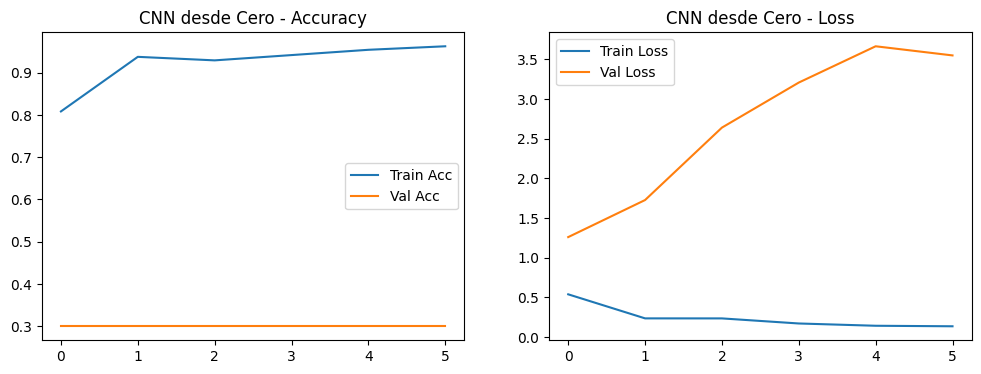

                    precision    recall  f1-score   support

complex_embroidery       0.00      0.00      0.00        20
 medium_embroidery       0.00      0.00      0.00        22
 simple_embroidery       0.30      1.00      0.46        18

          accuracy                           0.30        60
         macro avg       0.10      0.33      0.15        60
      weighted avg       0.09      0.30      0.14        60



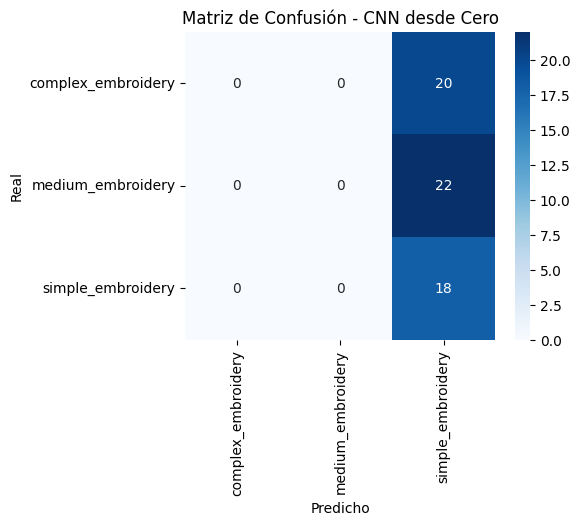

In [7]:
def plot_history_curves(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Acc')
    plt.plot(epochs_range, val_acc, label='Val Acc')
    plt.legend()
    plt.title(f'{title} - Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.legend()
    plt.title(f'{title} - Loss')
    plt.show()

def evaluate_and_confusion_matrix(model, dataset, classes, title):
    y_true, y_pred = [], []
    for imgs, lbls in dataset:
        preds = model.predict(imgs, verbose=0)
        y_true.extend(lbls.numpy())
        y_pred.extend(np.argmax(preds, axis=1))

    y_true, y_pred = np.array(y_true), np.array(y_pred)

    print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(f'Matriz de Confusión - {title}')
    plt.ylabel('Real')
    plt.xlabel('Predicho')
    plt.show()

    report = classification_report(y_true, y_pred, target_names=classes, output_dict=True, zero_division=0)
    return report['accuracy'], report['macro avg']['f1-score'], y_true, y_pred

plot_history_curves(history_cnn, "CNN desde Cero")
cnn_acc, cnn_f1, cnn_true, cnn_pred = evaluate_and_confusion_matrix(cnn_model, val_ds, class_names, "CNN desde Cero")


### Visualización de Interpretabilidad Espacial con Grad-CAM
Implementamos la técnica Grad-CAM para trazar el flujo de gradientes hacia la última capa convolucional (`act_block3`) de la CNN propia para entender qué regiones del parche de bordado activan la clasificación.


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 128, 128, 3))
  warnings.warn(msg)


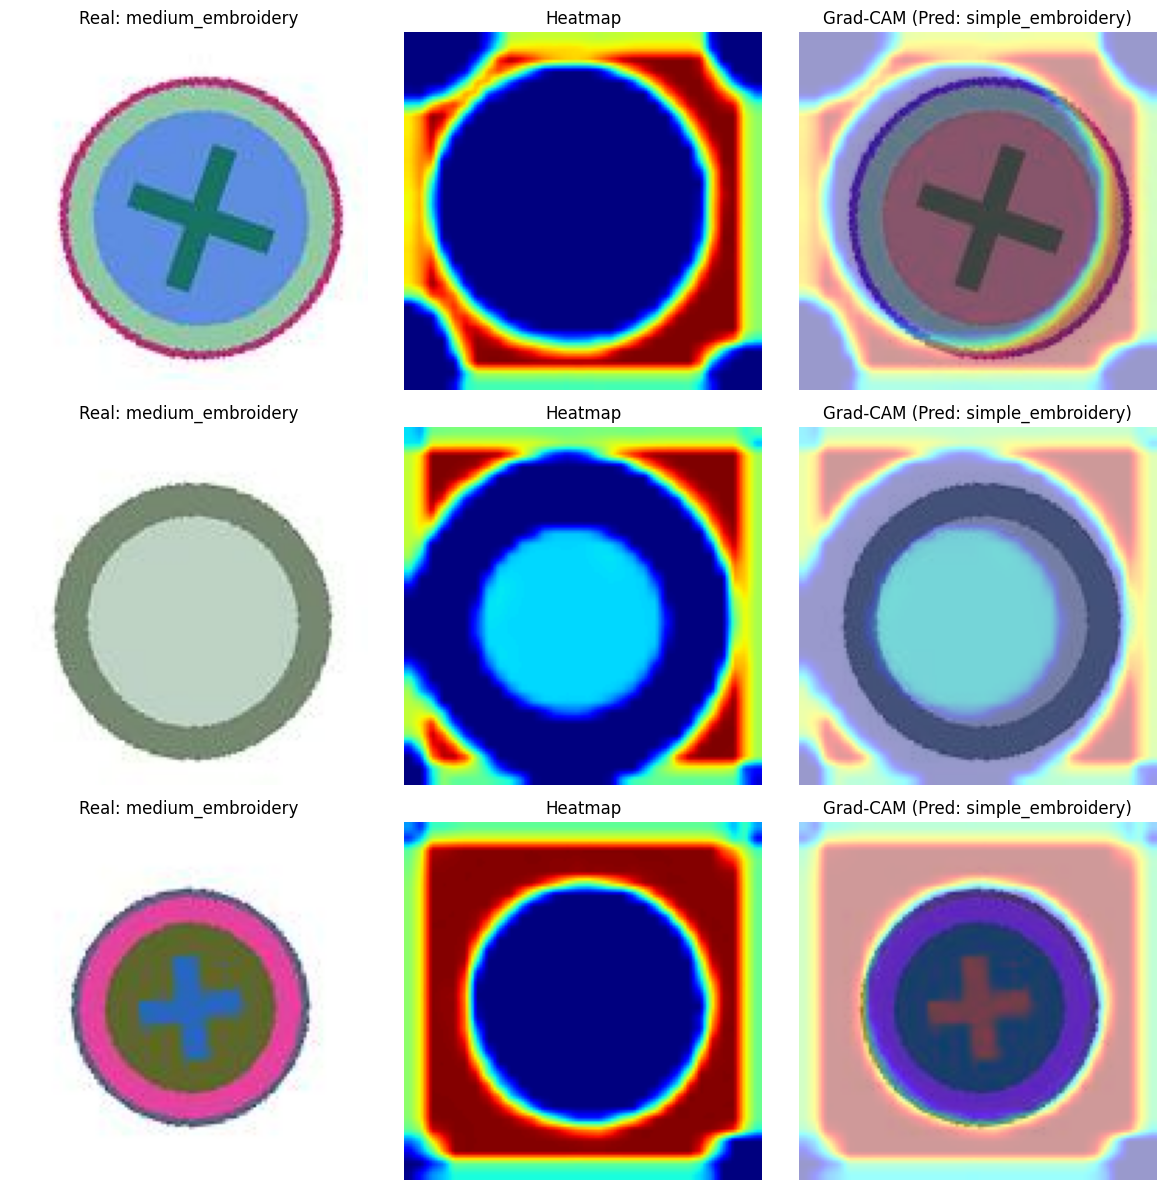

In [8]:
def get_gradcam_heatmap(model, img_array, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        model.inputs,
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def display_gradcam(model, dataset, classes, last_conv_layer):
    imgs, lbls = next(iter(dataset))

    plt.figure(figsize=(12, 12))
    for i in range(min(3, len(imgs))):
        img = imgs[i].numpy()
        lbl = lbls[i].numpy()

        img_array = np.expand_dims(img, axis=0)
        preds = model.predict(img_array, verbose=0)
        pred_idx = np.argmax(preds[0])

        heatmap = get_gradcam_heatmap(model, img_array, last_conv_layer, pred_idx)

        # Redimensionar heatmap
        img_uint8 = np.uint8(img)
        heatmap_resized = cv2.resize(heatmap, (img_uint8.shape[1], img_uint8.shape[0]))
        heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)

        # Superponer
        superimposed = heatmap_color * 0.4 + img_uint8 * 0.6
        superimposed = np.clip(superimposed, 0, 255).astype(np.uint8)

        # Graficar
        plt.subplot(3, 3, i*3 + 1)
        plt.imshow(np.uint8(img))
        plt.title(f"Real: {classes[lbl]}")
        plt.axis('off')

        plt.subplot(3, 3, i*3 + 2)
        plt.imshow(heatmap_resized, cmap='jet')
        plt.title("Heatmap")
        plt.axis('off')

        plt.subplot(3, 3, i*3 + 3)
        plt.imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
        plt.title(f"Grad-CAM (Pred: {classes[pred_idx]})")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

display_gradcam(cnn_model, val_ds, class_names, 'act_block3')


### Visualizar Errores de la CNN propia
Mostramos las imágenes que el modelo CNN desde cero clasificó incorrectamente.


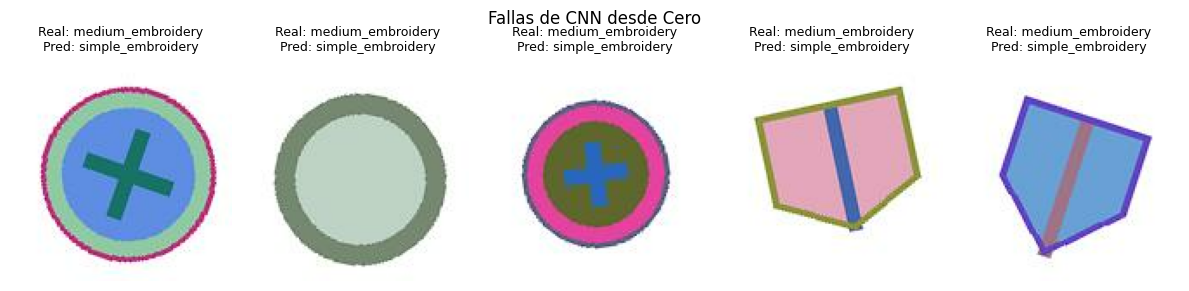

In [9]:
def plot_misclassified(model, dataset, classes, title):
    misclassified = []
    for imgs, lbls in dataset:
        preds = model.predict(imgs, verbose=0)
        pred_lbls = np.argmax(preds, axis=1)
        true_lbls = lbls.numpy()
        for i in range(len(true_lbls)):
            if pred_lbls[i] != true_lbls[i]:
                misclassified.append((imgs[i].numpy(), true_lbls[i], pred_lbls[i]))
            if len(misclassified) >= 5:
                break
        if len(misclassified) >= 5:
            break

    if not misclassified:
        print(f"No hay fallas para el modelo {title}.")
        return

    plt.figure(figsize=(12, 3))
    for idx, (img, true_l, pred_l) in enumerate(misclassified):
        plt.subplot(1, 5, idx+1)
        plt.imshow(np.uint8(img))
        plt.title(f"Real: {classes[true_l]}\nPred: {classes[pred_l]}", fontsize=9)
        plt.axis('off')
    plt.suptitle(f"Fallas de {title}")
    plt.tight_layout()
    plt.show()

plot_misclassified(cnn_model, val_ds, class_names, "CNN desde Cero")


## 4. PARTE C — Transfer Learning con MobileNetV2
Utilizamos la arquitectura preentrenada de **MobileNetV2** (pesos de `ImageNet`) para aprovechar los extractores de características genéricos.

### Fase 1: Feature Extraction
Congelamos el backbone base de MobileNetV2 y entrenamos únicamente el clasificador superior (la cabeza) por 10 épocas, con un Learning Rate estándar de $10^{-3}$ (0.001).


In [10]:
def build_mobilenet_model(num_classes):
    data_aug = get_data_augmentation()

    # Escalamiento requerido por MobileNetV2 [-1, 1]
    rescale_layer = layers.Rescaling(scale=1./127.5, offset=-1.0)

    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
        include_top=False,
        weights='imagenet'
    )
    # Congelar backbone
    base_model.trainable = False

    inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    x = data_aug(inputs)
    x = rescale_layer(x)
    x = base_model(x, training=False) # Mantener BatchNorm en inferencia (crítico)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs), base_model

mb_model, mb_base = build_mobilenet_model(len(class_names))
mb_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
mb_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Entrenando Fase 1: Feature Extraction...")
start_time = time.time()
history_mb_f1 = mb_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)
time_mb_f1 = time.time() - start_time
print(f"Fase 1 completada en {time_mb_f1:.2f} segundos.")


Entrenando Fase 1: Feature Extraction...
Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 369ms/step - accuracy: 0.8125 - loss: 0.5447 - val_accuracy: 0.9833 - val_loss: 0.0651
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 252ms/step - accuracy: 0.9917 - loss: 0.0325 - val_accuracy: 1.0000 - val_loss: 0.0157
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 351ms/step - accuracy: 0.9833 - loss: 0.0226 - val_accuracy: 1.0000 - val_loss: 0.0077
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 251ms/step - accuracy: 1.0000 - loss: 0.0026 - val_accuracy: 1.0000 - val_loss: 0.0038
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 267ms/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 1.0000 - val_loss: 0.0031
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 318ms/step - accuracy: 1.0000 - loss: 0.0045 - val_accuracy: 1.0000 - val_loss: 0.0056
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 255ms/step - accuracy: 0.9958 - loss: 0.0066 - val_accuracy: 1.0000 - val_loss: 0.0035
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 301ms/step - accuracy

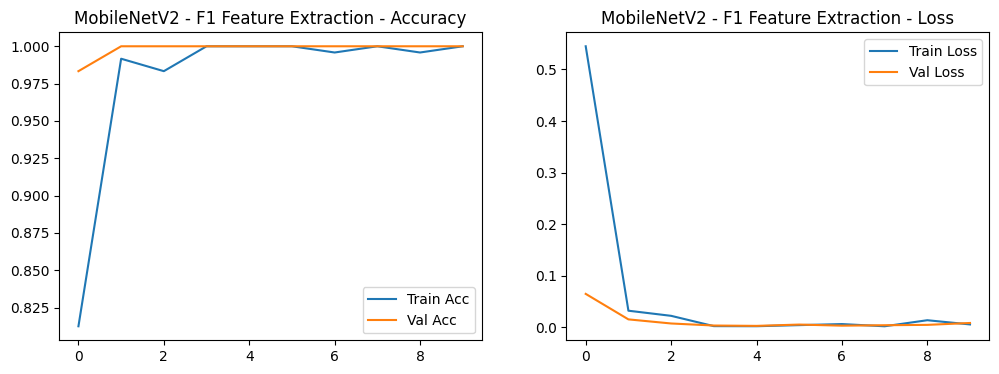

                    precision    recall  f1-score   support

complex_embroidery       1.00      1.00      1.00        20
 medium_embroidery       1.00      1.00      1.00        22
 simple_embroidery       1.00      1.00      1.00        18

          accuracy                           1.00        60
         macro avg       1.00      1.00      1.00        60
      weighted avg       1.00      1.00      1.00        60



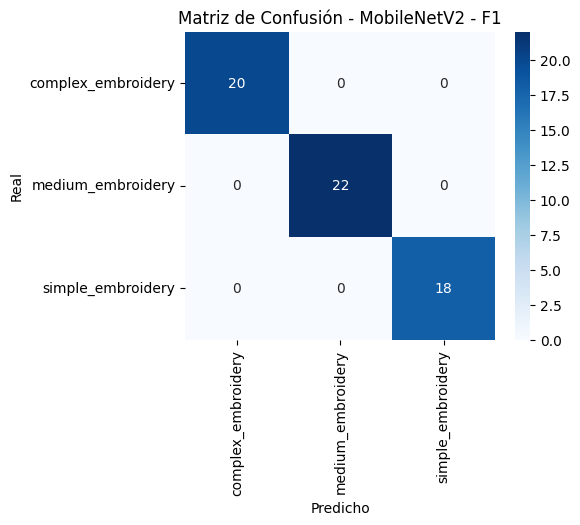

In [12]:
plot_history_curves(history_mb_f1, "MobileNetV2 - F1 Feature Extraction")
mb_f1_acc, mb_f1_f1, _, _ = evaluate_and_confusion_matrix(mb_model, val_ds, class_names, "MobileNetV2 - F1")


### Fase 2: Fine-Tuning
Descongelamos las últimas 30 capas de MobileNetV2 y entrenamos por 10 épocas adicionales.  
**Importante**: Para evitar destruir drásticamente los pesos preentrenados del extractor, se reduce el Learning Rate a un valor muy bajo: $10^{-5}$ (0.00001).


In [13]:
# Descongelar las últimas 30 capas
mb_base.trainable = True
print(f"Total capas en base: {len(mb_base.layers)}")

# Congelar todas excepto las últimas 30
for layer in mb_base.layers[:-30]:
    layer.trainable = False

# Recompilar con Learning Rate bajo
mb_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
mb_model.summary()


Total capas en base: 154


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 1,690,755 (6.45 MB)

 Non-trainable params: 731,584 (2.79 MB)

In [14]:
print("Entrenando Fase 2: Fine-Tuning...")
start_time = time.time()
history_mb_f2 = mb_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)
time_mb_f2 = time.time() - start_time
print(f"Fase 2 completada en {time_mb_f2:.2f} segundos.")


Entrenando Fase 2: Fine-Tuning...
Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 472ms/step - accuracy: 0.9292 - loss: 0.1744 - val_accuracy: 1.0000 - val_loss: 0.0045
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 440ms/step - accuracy: 0.9542 - loss: 0.1050 - val_accuracy: 1.0000 - val_loss: 0.0026
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 347ms/step - accuracy: 0.9750 - loss: 0.0686 - val_accuracy: 1.0000 - val_loss: 0.0020
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 366ms/step - accuracy: 0.9750 - loss: 0.0720 - val_accuracy: 1.0000 - val_loss: 0.0015
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 349ms/step - accuracy: 0.9833 - loss: 0.0540 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 449ms/step - accuracy: 0.9875 - loss: 0.0372 - val_accuracy: 1.0000 - val_loss: 0.0010
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 346ms/step - accuracy: 0.9958 - loss: 0.0234 - val_accuracy: 1.0000 - val_loss: 8.7860e-04
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 444ms/step - accuracy: 

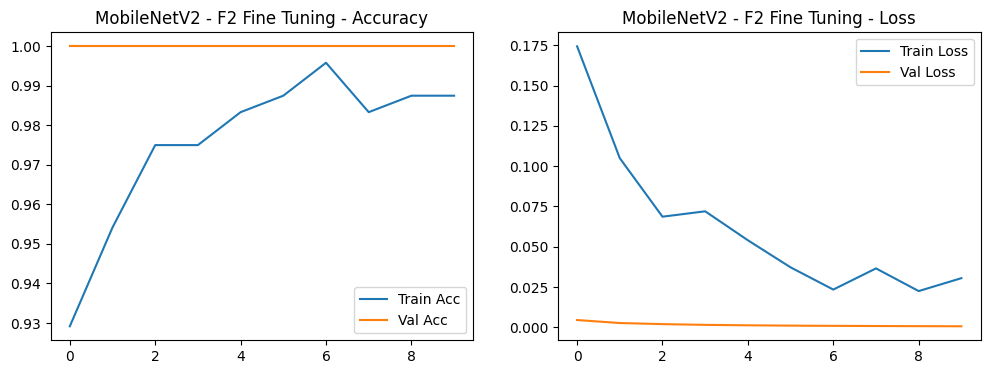

                    precision    recall  f1-score   support

complex_embroidery       1.00      1.00      1.00        20
 medium_embroidery       1.00      1.00      1.00        22
 simple_embroidery       1.00      1.00      1.00        18

          accuracy                           1.00        60
         macro avg       1.00      1.00      1.00        60
      weighted avg       1.00      1.00      1.00        60



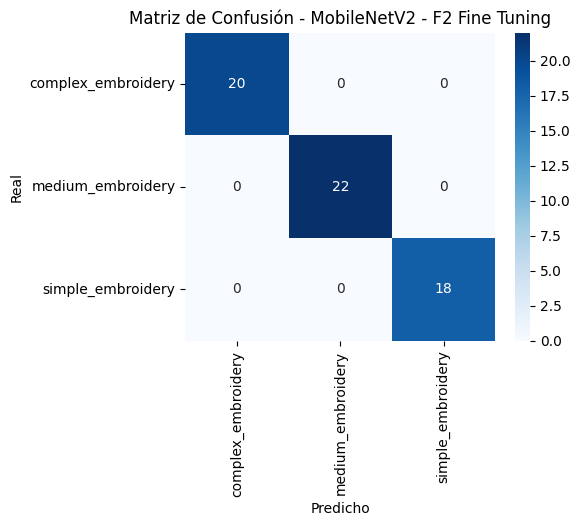

In [15]:
plot_history_curves(history_mb_f2, "MobileNetV2 - F2 Fine Tuning")
mb_f2_acc, mb_f2_f1, _, _ = evaluate_and_confusion_matrix(mb_model, val_ds, class_names, "MobileNetV2 - F2 Fine Tuning")


## 5. PARTE D — Auditoría y Mejora (CNN Mejorada)
La CNN propia entrenada desde cero sufre de sobreajuste severo debido a la memorización espacial de los bordados y el bajo volumen del dataset.  
Para mitigar esto, proponemos la **CNN Mejorada**:
1. Regularización penalizante L2 (`l2(0.001)`) en las capas de Convolución y Densas.
2. Estructura Conv-Conv-Pool duplicada en cada bloque.
3. Mayor tasa de abandono (`Dropout` incremental `[0.2, 0.3, 0.4]` y `0.5` en la cabeza).


In [16]:
def build_improved_cnn(num_classes):
    data_aug = get_data_augmentation()

    inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    x = data_aug(inputs)
    x = layers.Rescaling(1./255)(x)

    # Bloque 1
    x = layers.Conv2D(32, (3, 3), padding='same', kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.2)(x)

    # Bloque 2
    x = layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.3)(x)

    # Bloque 3
    x = layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu', name='act_improved_last')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.4)(x)

    # Cabeza
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs)

improved_model = build_improved_cnn(len(class_names))
improved_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Entrenando CNN Mejorada...")
start_time = time.time()
history_improved = improved_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop]
)
time_improved = time.time() - start_time
print(f"Entrenamiento de CNN Mejorada completado en {time_improved:.2f} segundos.")


Entrenando CNN Mejorada...
Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.7708 - loss: 0.8596 - val_accuracy: 0.3000 - val_loss: 1.4181
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.9083 - loss: 0.5449 - val_accuracy: 0.3000 - val_loss: 1.6609
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.9458 - loss: 0.4533 - val_accuracy: 0.3000 - val_loss: 1.9933
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.9208 - loss: 0.4515 - val_accuracy: 0.3000 - val_loss: 2.2747
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.9167 - loss: 0.4757 - val_accuracy: 0.3167 - val_loss: 2.2692
Entrenamiento de CNN Mejorada completado en 201.59 segundos.


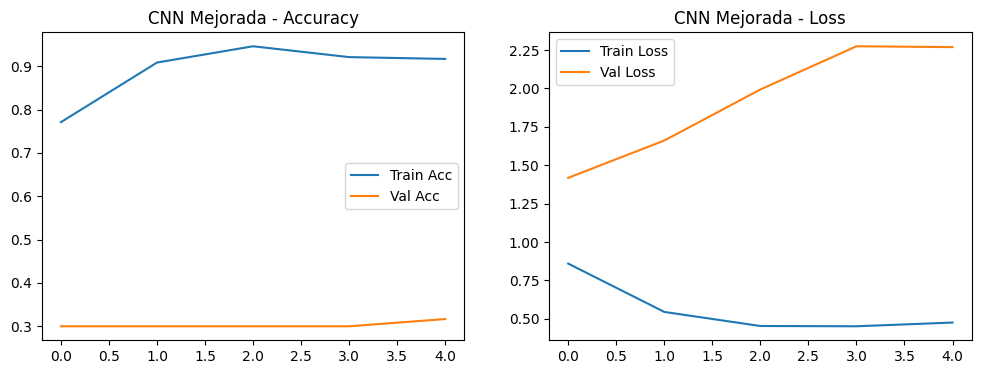

                    precision    recall  f1-score   support

complex_embroidery       0.00      0.00      0.00        20
 medium_embroidery       0.00      0.00      0.00        22
 simple_embroidery       0.30      1.00      0.46        18

          accuracy                           0.30        60
         macro avg       0.10      0.33      0.15        60
      weighted avg       0.09      0.30      0.14        60



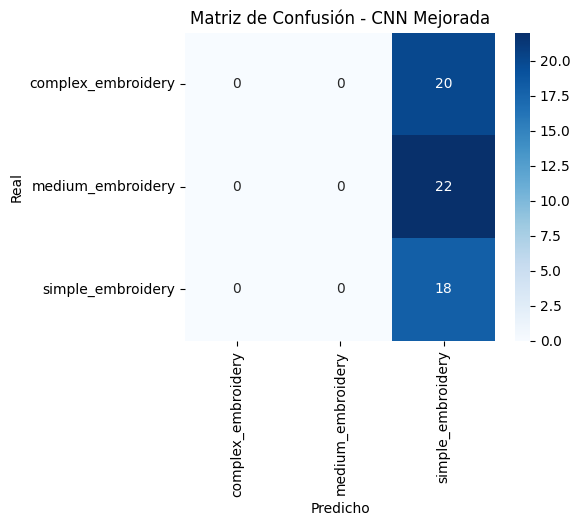

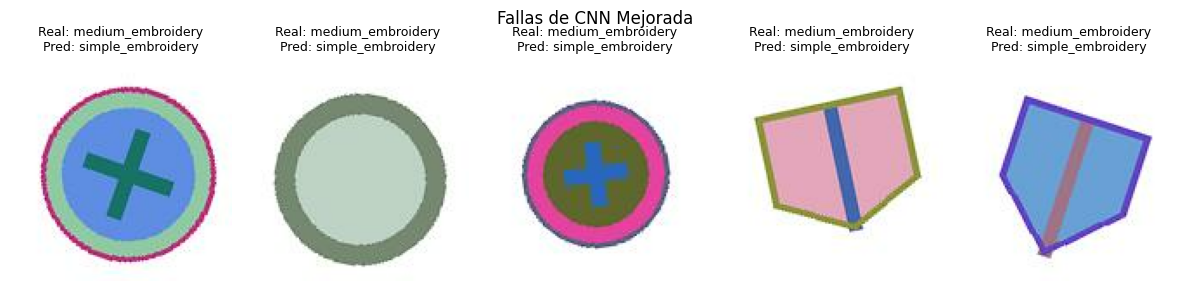

In [17]:
plot_history_curves(history_improved, "CNN Mejorada")
imp_acc, imp_f1, _, _ = evaluate_and_confusion_matrix(improved_model, val_ds, class_names, "CNN Mejorada")
plot_misclassified(improved_model, val_ds, class_names, "CNN Mejorada")


## 6. Comparación Unificada de Modelos
Consolidamos las métricas fundamentales en una tabla comparativa de acuerdo a los requerimientos.


In [18]:
def get_trainable_params(model):
    return sum([tf.size(v).numpy() for v in model.trainable_variables])

print(f"{'Modelo':<28} | {'Accuracy':<10} | {'F1 Macro':<10} | {'Parám. Entrenables':<18} | {'Tiempo (s)':<10}")
print("-" * 85)
print(f"{'CNN desde Cero':<28} | {cnn_acc:<10.4f} | {cnn_f1:<10.4f} | {get_trainable_params(cnn_model):<18d} | {time_cnn:<10.2f}")
print(f"{'MobileNetV2 (Feature Ext)':<28} | {mb_f1_acc:<10.4f} | {mb_f1_f1:<10.4f} | {get_trainable_params(mb_model):<18d} (Fase 1) | {time_mb_f1:<10.2f}")
print(f"{'MobileNetV2 (Fine Tuning)':<28} | {mb_f2_acc:<10.4f} | {mb_f2_f1:<10.4f} | {get_trainable_params(mb_model):<18d} (Fase 2) | {time_mb_f2:<10.2f}")
print(f"{'CNN Mejorada':<28} | {imp_acc:<10.4f} | {imp_f1:<10.4f} | {get_trainable_params(improved_model):<18d} | {time_improved:<10.2f}")


Modelo                       | Accuracy   | F1 Macro   | Parám. Entrenables | Tiempo (s)
-------------------------------------------------------------------------------------
CNN desde Cero               | 0.3000     | 0.1538     | 110595             | 115.09    
MobileNetV2 (Feature Ext)    | 1.0000     | 1.0000     | 1690755            (Fase 1) | 51.49     
MobileNetV2 (Fine Tuning)    | 1.0000     | 1.0000     | 1690755            (Fase 2) | 75.34     
CNN Mejorada                 | 0.3000     | 0.1538     | 305059             | 201.59    


## 7. Demostración e Inferencia Interactiva en Vivo
Ejecuta la celda inferior para cargar un archivo local de imagen (un diseño plano o escudo en JPG/PNG) y clasificar su complejidad al instante empleando el mejor modelo obtenido (`MobileNetV2 Fine-Tuned`).


Por favor, selecciona una imagen de tu computadora para clasificar...


Saving 4.png to 4.png


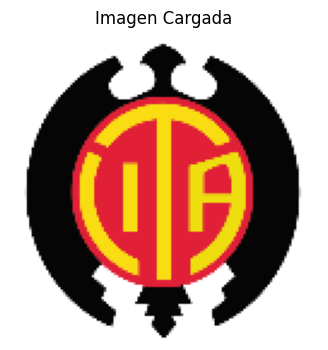


--- RESULTADO DE LA PREDICCIÓN ---
Imagen: 4.png
Complejidad de Bordado Estimada: SIMPLE_EMBROIDERY
Confianza del Modelo: 99.25%
 - complex_embroidery: 0.01%
 - medium_embroidery: 0.74%
 - simple_embroidery: 99.25%


In [19]:
from google.colab import files

try:
    print("Por favor, selecciona una imagen de tu computadora para clasificar...")
    uploaded = files.upload()

    for filename in uploaded.keys():
        # Cargar y preprocesar la imagen
        img_raw = cv2.imread(filename)
        img_rgb = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, IMG_SIZE)

        # Visualizar la imagen cargada
        plt.figure(figsize=(4, 4))
        plt.imshow(img_resized)
        plt.title("Imagen Cargada")
        plt.axis('off')
        plt.show()

        # Inferencia
        img_input = np.expand_dims(img_resized, axis=0)
        # MobileNetV2 requiere entrada en rango [-1, 1]
        img_normalized = (img_input / 127.5) - 1.0

        preds = mb_model.predict(img_normalized, verbose=0)
        class_idx = np.argmax(preds[0])
        prob = preds[0][class_idx]

        print(f"\n--- RESULTADO DE LA PREDICCIÓN ---")
        print(f"Imagen: {filename}")
        print(f"Complejidad de Bordado Estimada: {class_names[class_idx].upper()}")
        print(f"Confianza del Modelo: {prob * 100:.2f}%")

        # Mostrar probabilidades de todas las clases
        for idx, cls in enumerate(class_names):
            print(f" - {cls}: {preds[0][idx] * 100:.2f}%")
except Exception as e:
    print("Nota: Si estás corriendo esto en un entorno Jupyter local, la utilidad google.colab.files no estará disponible.")
    print("Excepción:", str(e))
